# 02 · P300 classification and character selection

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Train a shrinkage LDA detector on real EEG, evaluate an unseen session, and implement row/column evidence accumulation with explicitly simulated flash metadata.

**Data:** Real BNCI2014-009 target detection; separate labeled speller simulation

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### P300 spelling and selective attention

A P300 speller transforms selective attention into a discrete selection. The participant attends to a designated symbol while groups of symbols are intensified. A flash containing the attended symbol is a target; another flash is a non-target. These are stimulus-level labels, whereas the intended character is a selection-level label. The distinction is essential: target detection accuracy is not character selection accuracy.

The P300 is an event-related positive deflection whose amplitude and latency depend on attention, task demands and stimulus probability. “300” is a conventional designation rather than a fixed latency. A target-minus-non-target waveform can contain several components, and a positive peak alone does not establish reliable communication. Repetition supports averaging or evidence accumulation at the cost of selection time. Gaze, fatigue and stimulus timing may influence performance.

A minimal instructional experiment uses a symbol matrix, a stimulus computer, an EEG amplifier and scalp electrodes, and synchronized stimulus markers. The participant receives an intended symbol, observes randomized flashes, and counts or attends to target flashes. Each marker must identify flash onset and stimulus identity; the target instruction supplies the target/non-target label. Selection identifiers and repetition indices must be retained if character decoding is intended. This is an illustrative design, not a reconstruction of undocumented timing in the downloaded files.

### Acquisition provenance and instructional protocol

BNCI2014-009 grid-speller data; 16 EEG channels, 256 Hz original sampling, three sessions in the selected subject. MOABB supplies MNE-compatible epochs. This is a BNCI-hosted P300 dataset, not Competition IV 2a.

**Acquisition reference:** [BNCI2014_009 dataset and loader documentation](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Flash onset → target/non-target epoch → repeated evidence → character selection. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

For feature vector $z\in\mathbb R^d$, LDA uses $g(z)=w^\top z+b$, where $w=\Sigma^{-1}(\mu_1-\mu_0)$ under a shared covariance model. A regularized covariance can be written $\Sigma_\lambda=(1-\lambda)\hat\Sigma+\lambda\tau I$. The decision threshold controls sensitivity and specificity; a ranking score is not necessarily a calibrated probability. For candidate character $a$, repeated evidence is $S(a)=\sum_r\sum_{j\in\mathcal F(a,r)}g(z_j)$, where $\mathcal F$ requires known flash identities and repetitions.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


**Methodological reading:** [Farwell and Donchin (1988). Talking off the top of your head: toward a mental prosthesis utilizing event-related brain potentials](https://doi.org/10.1016/0013-4694(88)90149-6). Foundational P300 spelling experiment.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Derive a two-class LDA direction and explain covariance shrinkage.
- Separate fitting, probability/ranking scores and threshold decisions.
- Compute confusion-matrix metrics by hand before using library functions.
- Aggregate row/column evidence while preserving character and repetition IDs.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

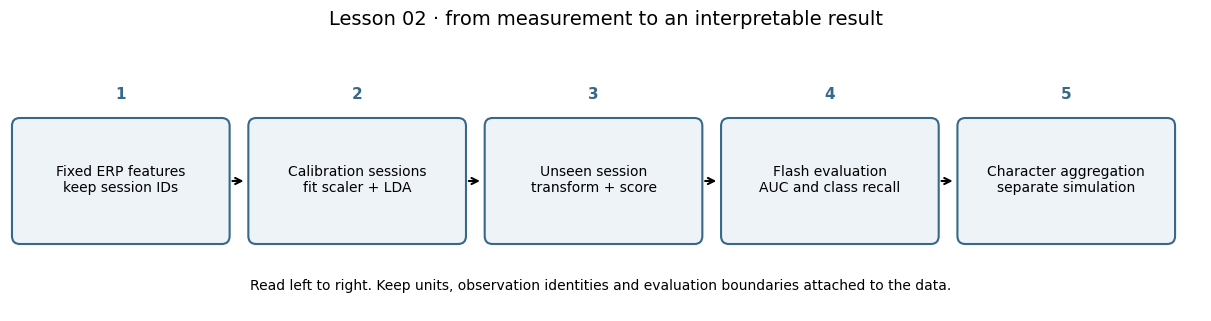

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Fixed ERP features\nkeep session IDs', 'Calibration sessions\nfit scaler + LDA', 'Unseen session\ntransform + score', 'Flash evaluation\nAUC and class recall', 'Character aggregation\nseparate simulation']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 02 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Fixed ERP features: keep session IDs → Calibration sessions: fit scaler + LDA → Unseen session: transform + score → Flash evaluation: AUC and class recall → Character aggregation: separate simulation.

## Symbols and a calculation by hand

$\mu_k$: class mean vector; $\Sigma$: shared covariance; $w,b$: linear score parameters; TP/FN/FP/TN: confusion counts.

### Derive the operation before calling the library

Under Gaussian classes with a shared covariance, the quadratic terms cancel in the log-likelihood ratio. The remaining feature-dependent term is $w^Tx$, where $w=\Sigma^{-1}(\mu_1-\mu_0)$. The intercept incorporates mean offsets and prior class probabilities. Solve a linear system instead of explicitly inverting a noisy covariance matrix.

For $TP=6,FN=4,TN=80,FP=10$, target recall is $6/10=0.6$ and non-target recall is $80/90\approx0.889$. Balanced accuracy is their mean, about 0.744. Ordinary accuracy is $86/100=0.86$. These are different answers to different questions. AUC uses score ordering over thresholds; it cannot be recovered from just one confusion matrix.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### From a feature vector to a decision

Let $z\in\mathbb R^p$ contain the temporal means from several channels and windows. LDA assumes $z|y=k\sim\mathcal N(\mu_k,\Sigma)$ with one shared covariance. Subtracting the two log Gaussian densities cancels their common quadratic term, leaving a linear score:

$$g(z)=z^T\Sigma^{-1}(\mu_1-\mu_0)-\tfrac12(\mu_1+\mu_0)^T\Sigma^{-1}(\mu_1-\mu_0)+\log(\pi_1/\pi_0).$$

Here $\pi_k$ is the class prior. The direction says which combination of features separates the means after accounting for covariance. The intercept includes prior odds: targets are rarer, so equal evidence need not imply a target decision. A classifier with useful AUC may still miss many targets at its default threshold.

Why covariance? Two neighboring EEG features may contain nearly the same information. Counting both as independent would overstate the evidence. But estimating a full $p\times p$ covariance requires many parameters; with correlated or scarce trials the inverse becomes unstable. Shrinkage pulls the estimate toward a simpler matrix. It trades some bias for reduced estimation variance. Standardization is learned from training data, not a ritual to perform on the entire dataset first.

### Choose a metric that matches the question

Accuracy counts correct decisions; balanced accuracy averages recalls so the abundant class does not dominate. ROC AUC assesses ordering over all thresholds. Average precision emphasizes precision/recall in the positive class and its baseline depends on positive prevalence. None measures the number of correctly typed characters per minute. Report the unit of prediction and the unit of communication separately.

In this lesson the first sessions calibrate a fixed model and the last session evaluates it. Inspecting that last score repeatedly while changing features would turn it into a validation set. The later controlled speller simulation has known flash identities, so aggregation can be checked exactly; it does not upgrade the real-data experiment into a validated text-entry system.

## Visual intuition · A threshold moves two kinds of error

**Independent exercise:** Move the marked threshold mentally to the right. Which error decreases, and which increases?

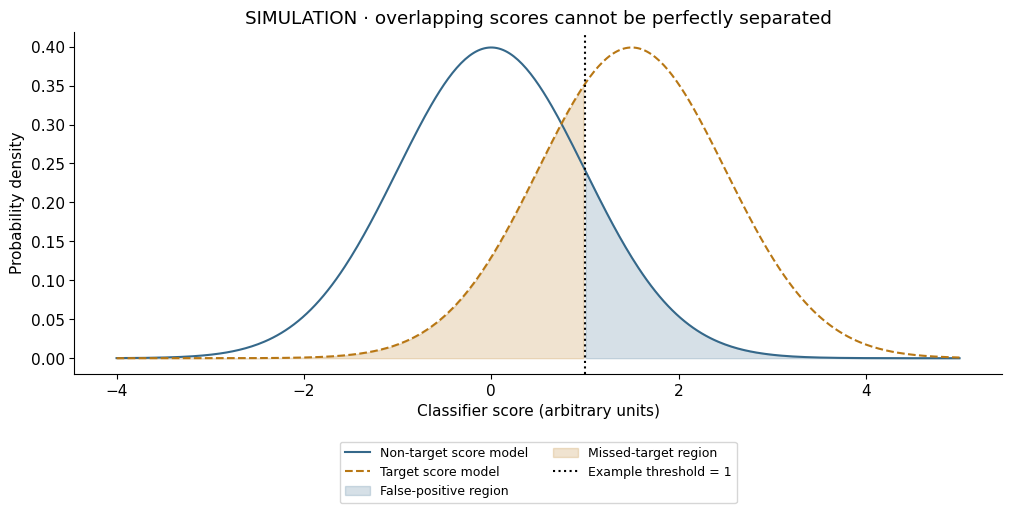

In [3]:
from scipy.stats import norm
vis_score=np.linspace(-4,5,400)
fig,ax=plt.subplots(figsize=(10,5),constrained_layout=True)
ax.plot(vis_score,norm.pdf(vis_score,0,1),label='Non-target score model',color='#35688a')
ax.plot(vis_score,norm.pdf(vis_score,1.5,1),label='Target score model',color='#b87714',linestyle='--')
ax.fill_between(vis_score,0,norm.pdf(vis_score,0,1),where=vis_score>=1,color='#35688a',alpha=.2,label='False-positive region')
ax.fill_between(vis_score,0,norm.pdf(vis_score,1.5,1),where=vis_score<1,color='#b87714',alpha=.2,label='Missed-target region')
ax.axvline(1,color='black',linestyle=':',label='Example threshold = 1')
ax.set(xlabel='Classifier score (arbitrary units)',ylabel='Probability density',title='SIMULATION · overlapping scores cannot be perfectly separated')
ax.legend(ncol=2,fontsize=9,loc='upper center',bbox_to_anchor=(.5,-.18));plt.show()

### Worked interpretation

A higher threshold reduces non-target false alarms but misses more targets. AUC summarizes ranking, while a deployed decision requires an operating threshold chosen on calibration data. These curves are illustrative distributions, not fitted distributions of the actual subject.

## Guided practice 1 · solve a two-feature LDA direction

Two feature means differ in both coordinates, but the first coordinate has much larger within-class variance. Predict which feature receives more weight. Use a linear solver rather than explicitly inverting the covariance.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_mu0=np.array([0.,0.]);demo_mu1=np.array([1.,1.])
demo_cov=np.diag([4.,.25])
demo_w=np.linalg.solve(demo_cov,demo_mu1-demo_mu0)
print('LDA direction:',demo_w)
print('Mean contrast before covariance adjustment:',demo_mu1-demo_mu0)
assert demo_w[1]>demo_w[0]

LDA direction: [0.25 4.  ]
Mean contrast before covariance adjustment: [1. 1.]


### Why this result makes sense

The less variable feature gets a larger weight in this example. Large weights are not automatically large physiological effects; units and covariance matter.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · compute the confusion matrix metrics

Suppose 80 non-target flashes are classified correctly, 10 become false targets, 6 targets are detected and 4 are missed. Compute accuracy, precision, recall and balanced accuracy before reading the output.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
TN,FP,TP,FN=80,10,6,4
manual_metrics={'accuracy':(TP+TN)/(TP+TN+FP+FN),
 'target_precision':TP/(TP+FP),'target_recall':TP/(TP+FN),
 'balanced_accuracy':.5*(TP/(TP+FN)+TN/(TN+FP))}
print(pd.Series(manual_metrics).round(3))

accuracy             0.860
target_precision     0.375
target_recall        0.600
balanced_accuracy    0.744
dtype: float64


### Why this result makes sense

The overall accuracy can look comfortable while target precision is poor. An interface may need more repetitions or a rejection state even when ranking performance is useful.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · move the threshold

Hold scores fixed and change only the threshold. This changes decisions, not the underlying ranking. The following data are synthetic, so the curve explains a tradeoff rather than reporting participant performance.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

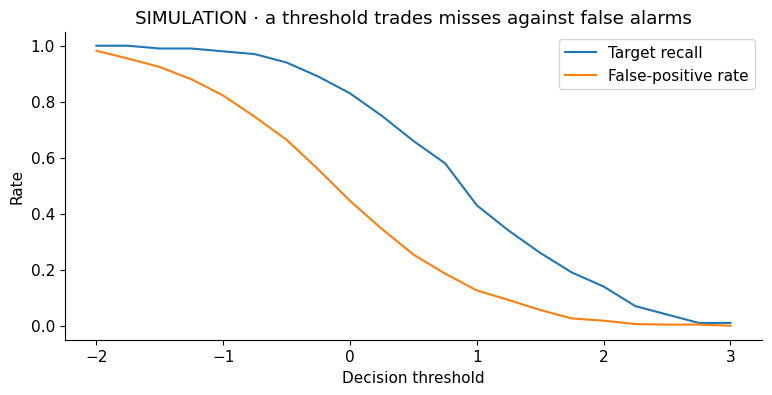

In [6]:
demo_y=np.r_[np.zeros(500,dtype=int),np.ones(100,dtype=int)]
demo_scores=rng.normal(demo_y*.9,1)
threshold_rows=[]
for threshold in np.linspace(-2,3,21):
    decision=demo_scores>=threshold
    recall=decision[demo_y==1].mean()
    false_positive=decision[demo_y==0].mean()
    threshold_rows.append((threshold,recall,false_positive))
threshold_rows=np.array(threshold_rows)
fig,ax=plt.subplots()
ax.plot(threshold_rows[:,0],threshold_rows[:,1],label='Target recall')
ax.plot(threshold_rows[:,0],threshold_rows[:,2],label='False-positive rate')
ax.set(xlabel='Decision threshold',ylabel='Rate',title='SIMULATION · a threshold trades misses against false alarms')
ax.legend();plt.show()

### Why this result makes sense

Do not choose an operating threshold using the evaluation labels. A separate validation set or grouped calibration predictions are needed.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · evidence accumulation by hand

Flash groups 0–5 denote rows and 6–11 columns. Add evidence across repetitions first, then take separate maxima. Taking one maximum over all twelve groups would produce a group, not a character.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_scores_grid=np.zeros((1,3,12))
demo_scores_grid[0,:,2]=[.5,1.,.7]
demo_scores_grid[0,:,10]=[.6,.8,1.2]
demo_totals=demo_scores_grid.sum(1)
demo_row=demo_totals[:,:6].argmax(1)
demo_col=demo_totals[:,6:].argmax(1)
print('Row, column:',demo_row,demo_col)
print('Flat symbol index:',demo_row*6+demo_col)
assert (demo_row*6+demo_col)[0]==16

Row, column: [2] [4]
Flat symbol index: [16]


### Why this result makes sense

Aggregation requires correct flash-group metadata. It cannot be reconstructed safely from binary target labels alone.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Metrics from counts

Implement `balanced_from_counts`. Verify it gives 0.5 for an all-non-target classifier when both classes exist, regardless of imbalance.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def balanced_from_counts(tn, fp, fn, tp):
    # TODO: average the target and non-target recalls.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def balanced_from_counts(tn,fp,fn,tp):
    if tp+fn==0 or tn+fp==0: raise ValueError('Both classes required')
    return .5*(tp/(tp+fn)+tn/(tn+fp))

In [10]:
answer=balanced_from_counts(80,10,4,6)
if answer is not None:
    assert np.isclose(answer,.5*(80/90+6/10)); print('Metric checks passed.')
else:
    print('Exercise pending: implement balanced_from_counts.')

Metric checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

Linear discriminant analysis models each class with a mean $\mu_k$ and a common covariance $\Sigma$. Its binary direction is $w=\Sigma^{-1}(\mu_1-\mu_0)$. Shrinkage uses $\Sigma_\lambda=(1-\lambda)\hat\Sigma+\lambda\alpha I$ to stabilize estimates when features are numerous or correlated. Scaling and covariance estimation belong inside the training pipeline.

ROC AUC measures ranking over thresholds: it is the probability a random target receives a higher score than a random non-target. Balanced accuracy is $(\mathrm{TPR}+\mathrm{TNR})/2$. Neither equals character accuracy. A row/column decoder adds flash evidence: $S_j=\sum_r s_{rj}$, then chooses the row and column with largest accumulated score. The mapping from flash to row/column must come from the experiment log; binary target labels cannot reconstruct it.

For $M$ equally likely commands, accuracy $P$ and decision duration $T$ seconds, the idealized information-transfer rate is $\mathrm{ITR}=\frac{60}{T}[\log_2 M+P\log_2P+(1-P)\log_2\frac{1-P}{M-1}]$. Its symmetric-error and independent-selection assumptions can fail; report actual selection time, correction time and a confusion matrix too.

## Load and separate sessions
Keep the final session completely outside fitting. All preprocessing settings are fixed in advance.

The final session is reserved before model fitting. The temporal windows are fixed in advance, and the label vector remains aligned with the metadata. Keeping entire sessions separate prevents trial-level random splitting from obscuring recording-session transfer.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Import the named tools used in this step.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Declare the public P300 preprocessing and epoching contract before loading.

**5.** Expose the numerical array; EEG values are in volts and the final axis is time.

**6.** Make an explicit NumPy vector while preserving its current row order.

**7.** Expose the numerical array; EEG values are in volts and the final axis is time.

In [11]:
# Import the named tools used in this step.
from moabb.datasets import BNCI2014_009
# Import the named tools used in this step.
from moabb.paradigms import P300
# Store this intermediate result so the next operation can be traced and inspected.
dataset = BNCI2014_009()
# Declare the public P300 preprocessing and epoching contract before loading.
paradigm = P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)
# Expose the numerical array; EEG values are in volts and the final axis is time.
epochs, labels, metadata_p300 = paradigm.get_data(dataset=dataset, subjects=[1], return_epochs=True)
# Make an explicit NumPy vector while preserving its current row order.
y = (np.asarray(labels) == 'Target').astype(int)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


### Step 1.2 · trace the next operation

**1.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**2.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**3.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**4.** Make an explicit NumPy vector while preserving its current row order.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**6.** Create an explicit partition mask; use the same mask for data, labels and metadata.

**7.** Create an explicit partition mask; use the same mask for data, labels and metadata.

In [12]:
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
session = metadata_p300['session'].astype(str).to_numpy()
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert X.shape[0] == len(y) == len(session)
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert set(np.unique(y)) == {0, 1}
# Make an explicit NumPy vector while preserving its current row order.
print(pd.crosstab(session, np.asarray(labels)))
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Shape:', X.shape, 'sampling:', epochs.info['sfreq'], 'Hz')
# Create an explicit partition mask; use the same mask for data, labels and metadata.
train = session != sorted(np.unique(session))[-1]
# Create an explicit partition mask; use the same mask for data, labels and metadata.
test = ~train

col_0  NonTarget  Target
row_0                   
0            480      96
1            480      96
2            480      96
Shape: (1728, 16, 103) sampling: 128.0 Hz


### Step 1.3 · trace the next operation

**1.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**2.** Join arrays along the declared axis; preserve the trial ordering.

**3.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

In [13]:
# Make the analysis choice visible and fixed before inspecting evaluation performance.
windows = [(0.1, 0.25), (0.25, 0.4), (0.4, 0.6), (0.6, 0.8)]
# Join arrays along the declared axis; preserve the trial ordering.
features = np.concatenate([X[:, :, (epochs.times >= a) & (epochs.times < b)].mean(-1) for a, b in windows], axis=1)
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert set(session[train]).isdisjoint(set(session[test]))

### Inspect and interpret

Print the session identifiers assigned to each partition and verify no overlap. Check that both classes occur in calibration and test. A pipeline cannot repair an incorrectly constructed partition.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Inspect the locked session split

**Independent exercise:** Print class counts on both sides and verify the session sets do not overlap.

**My reasoning / hand calculation:** _write here._

In [14]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Index both labels and session metadata with the same Boolean masks.

### Worked solution

Run the following calculation after attempting your own version.

In [15]:
print('Calibration sessions:',np.unique(session[train]))
print('Test sessions:',np.unique(session[test]))
print(pd.crosstab(np.where(train,'calibration','test'),y))
assert set(session[train]).isdisjoint(set(session[test]))

Calibration sessions: ['0' '1']
Test sessions: ['2']
col_0          0    1
row_0                
calibration  960  192
test         480   96


### Interpret and check

This proves the implemented session identifiers are disjoint. It does not establish independence between different people: all data still belong to one participant. Keep that limit in the result statement.

## Fit and evaluate
LDA priors reflect training prevalence. AUC uses continuous scores; threshold-based metrics use the default decision boundary, without test-set tuning.

The scaler learns only calibration statistics; shrinkage LDA then estimates a regularized linear discriminant. `decision_function` yields continuous scores for AUC, while `predict` gives labels for balanced accuracy and the confusion matrix. These metrics answer different questions.

### Step 2.1 · trace the next operation

**1.** Keep learned preprocessing and the classifier inside the same fitting boundary.

**2.** Estimate all pipeline parameters from the training partition only.

**3.** Obtain continuous class scores for ranking metrics rather than hard predictions.

**4.** Apply the already-fitted estimator to observations excluded from fitting.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**6.** Average class recalls so majority-class frequency does not dominate the score.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [16]:
# Keep learned preprocessing and the classifier inside the same fitting boundary.
model = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
# Estimate all pipeline parameters from the training partition only.
model.fit(features[train], y[train])
# Obtain continuous class scores for ranking metrics rather than hard predictions.
scores = model.decision_function(features[test])
# Apply the already-fitted estimator to observations excluded from fitting.
pred = model.predict(features[test])
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Held-out session AUC:', roc_auc_score(y[test], scores))
# Average class recalls so majority-class frequency does not dominate the score.
print('Balanced accuracy:', balanced_accuracy_score(y[test], pred))
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(classification_report(y[test], pred, target_names=['Non-target', 'Target'], zero_division=0))

Held-out session AUC: 0.8749131944444444
Balanced accuracy: 0.7333333333333334
              precision    recall  f1-score   support

  Non-target       0.91      0.95      0.93       480
      Target       0.66      0.52      0.58        96

    accuracy                           0.88       576
   macro avg       0.78      0.73      0.75       576
weighted avg       0.87      0.88      0.87       576



### Step 2.2 · trace the next operation

**1.** Show which true classes are confused at the current decision rule.

**2.** Render the completed figure and inspect labels, units and the comparison.

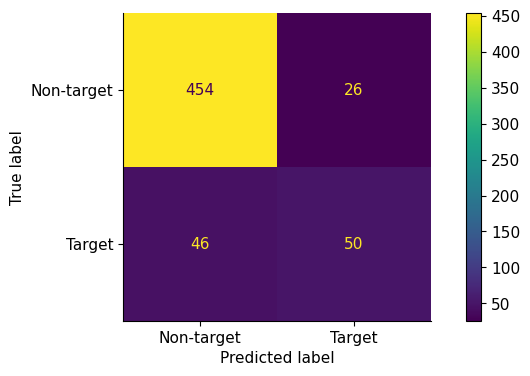

In [17]:
# Show which true classes are confused at the current decision rule.
ConfusionMatrixDisplay.from_predictions(y[test], pred, display_labels=['Non-target', 'Target'])
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Read the target recall and non-target recall separately. Explain how a model can rank targets reasonably while producing few target predictions at its default threshold. Any threshold change must be selected on calibration data.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Recover balanced accuracy from the confusion matrix

**Independent exercise:** Calculate target and non-target recall by hand from the displayed matrix, then check their mean.

**My reasoning / hand calculation:** _write here._

In [18]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

True classes are rows. Divide each diagonal entry by its row sum.

### Worked solution

Run the following calculation after attempting your own version.

In [19]:
from sklearn.metrics import confusion_matrix
lab_cm=confusion_matrix(y[test],pred,labels=[0,1])
lab_recall=np.diag(lab_cm)/lab_cm.sum(axis=1)
print('Confusion matrix:\n',lab_cm)
print('Non-target / target recalls:',lab_recall)
print('Their mean:',lab_recall.mean())
assert np.isclose(lab_recall.mean(),balanced_accuracy_score(y[test],pred))

Confusion matrix:
 [[454  26]
 [ 46  50]]
Non-target / target recalls: [0.94583333 0.52083333]
Their mean: 0.7333333333333334


### Interpret and check

The average of the two recalls matches balanced accuracy. It may be well below ordinary accuracy because the numerous non-target observations dominate the latter. Do not select a new threshold from this test matrix and still call the result untouched.

## Practice 4 · Design a threshold-selection protocol

**Independent exercise:** Explain how to choose a more sensitive operating threshold while preserving a final test session.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Use the available calibration sessions to generate validation scores.

### Worked solution

Within calibration data, obtain held-out scores using session or character groups consistent with the experiment. Choose the threshold for a stated objective such as target recall subject to a false-positive limit. Refit the model on calibration data, freeze the threshold, then evaluate once on the final session. AUC does not itself specify the operating threshold.

## Decode characters with known flash identity
This separate simulation teaches aggregation only. Scores are simulated, not predictions on the real speller data; do not report its accuracy as experimental performance.

The next example is explicitly synthetic because trial classification alone does not preserve the full character-selection protocol. Known row and column flash identities let us sum evidence across repetitions and select their intersection. No real-data spelling accuracy is inferred from this simulation.

### Step 3.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Store this intermediate result so the next operation can be traced and inspected.

In [20]:
# Store this intermediate result so the next operation can be traced and inspected.
alphabet = np.array(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')).reshape(6, 6)
# Store this intermediate result so the next operation can be traced and inspected.
n_characters, repetitions = (100, 10)
# Store this intermediate result so the next operation can be traced and inspected.
truth = rng.integers(0, 36, n_characters)
# Store this intermediate result so the next operation can be traced and inspected.
flash_scores = rng.normal(0, 1, (n_characters, repetitions, 12))

### Step 3.2 · trace the next operation

**1.** Repeat this operation over the explicitly listed groups while keeping their identities attached.

In [21]:
# Repeat this operation over the explicitly listed groups while keeping their identities attached.
for i, target in enumerate(truth):
    row, col = divmod(int(target), 6)
    flash_scores[i, :, row] += 0.8
    flash_scores[i, :, 6 + col] += 0.8

### Step 3.3 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

In [22]:
# Store this intermediate result so the next operation can be traced and inspected.
accuracy = []

### Step 3.4 · trace the next operation

**1.** Repeat this operation over the explicitly listed groups while keeping their identities attached.

In [23]:
# Repeat this operation over the explicitly listed groups while keeping their identities attached.
for r in range(1, repetitions + 1):
    total = flash_scores[:, :r].sum(axis=1)
    selected = total[:, :6].argmax(1) * 6 + total[:, 6:].argmax(1)
    accuracy.append(np.mean(selected == truth))

### Step 3.5 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Render the completed figure and inspect labels, units and the comparison.

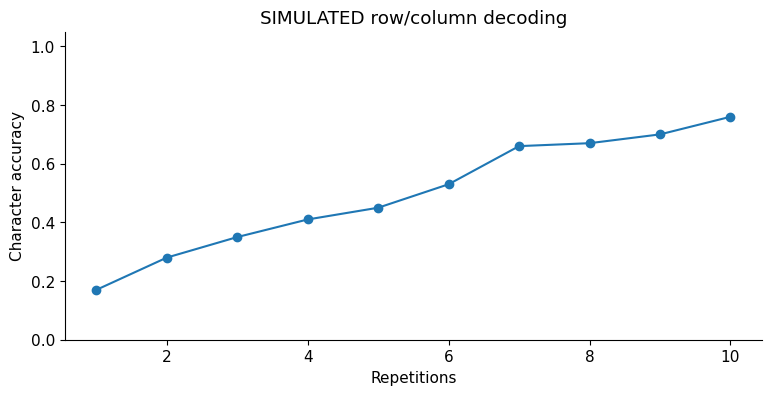

In [24]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.plot(range(1, repetitions + 1), accuracy, 'o-')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Repetitions', ylabel='Character accuracy', ylim=(0, 1.05), title='SIMULATED row/column decoding')
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Step 3.6 · trace the next operation

**1.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [25]:
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Example target:', alphabet.flat[truth[0]], 'decoded:', alphabet.flat[selected[0]])

Example target: Y decoded: 2


### Inspect and interpret

Check that the intended character is recoverable from its row and column. Repeat with fewer repetitions or noisier scores. Explain why flashes from the same character must remain together in a character-level evaluation.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 5 · Decode a row/column decision manually

**Independent exercise:** If accumulated row scores peak at row 2 and column scores peak at column 4, what symbol is selected in the displayed alphabet?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Flat index = row × 6 + column.

### Worked solution

The flat index is 2×6+4=16, corresponding to Q in the zero-based alphabet grid. Summing across repetitions reduces independent score noise in the simulation, but real errors can be correlated and real flash schedules must be retained.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

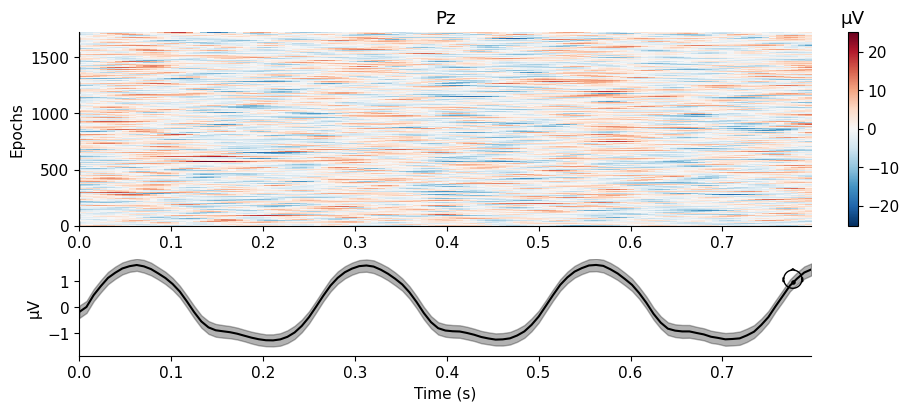

In [26]:
# Display individual recorded trials with MNE's epoch-image API.
inspection_epochs = epochs.copy().pick(['Pz'])
inspection_epochs.plot_image(picks=['Pz'], sigma=0, show=False)
plt.show()

### Figure interpretation and independent exercise

The image displays individual trials at Pz; colour encodes voltage and the lower panel summarizes the evoked response. Inspect amplitude variability and temporal alignment. For motor imagery and SSVEP, a weak signed average can coexist with substantial induced or frequency-locked power; interpret this display alongside the spectral analysis. Trial order follows the loaded epoch object and is not a randomized validation split.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

The image pools target and non-target trials. Its lower trace is therefore a pooled average, not the target P300 or a target-minus-non-target contrast. Use the condition-specific plots earlier in the lesson to examine that distinction.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

AUC evaluates score ranking; balanced accuracy averages class recalls at one decision rule; character accuracy evaluates a complete selection protocol. A threshold or model chosen from a final test session invalidates the untouched-test claim.

## If your result is different

If target recall is low but AUC is reasonable, distinguish ranking from threshold behavior. Select any new threshold inside calibration; do not tune against the final test confusion matrix.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[LDA](https://scikit-learn.org/stable/modules/lda_qda.html) · [P300 dataset](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [BNCI2014_009 dataset and loader documentation](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.


### Primary methodological literature

- [Farwell and Donchin (1988). Talking off the top of your head: toward a mental prosthesis utilizing event-related brain potentials](https://doi.org/10.1016/0013-4694(88)90149-6). Foundational P300 spelling experiment.